In [14]:
import pandas as pd
from pulp import *

In [15]:
!pip install pulp


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
from pulp import *

In [18]:
import os

In [19]:
folder = r'C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization'

manvar_costs  = pd.read_excel(os.path.join(folder, 'variable_costs.xlsx'), index_col=0)
freight_costs = pd.read_excel(os.path.join(folder, 'freight_costs.xlsx'),  index_col=0)
fixed_costs   = pd.read_excel(os.path.join(folder, 'fixed_cost.xlsx'),     index_col=0)
cap           = pd.read_excel(os.path.join(folder, 'capacity.xlsx'),        index_col=0)
demand        = pd.read_excel(os.path.join(folder, 'demand.xlsx'),          index_col=0)

print("All files loaded successfully!")

All files loaded successfully!


In [20]:
var_cost = freight_costs / 1000 + manvar_costs

In [21]:
loc  = ['USA', 'Germany', 'Japan', 'Brazil', 'India']
size = ['Low', 'High']

model = LpProblem("Supply Chain Optimization", LpMinimize)

x = LpVariable.dicts("production_",
        [(i,j) for i in loc for j in loc],
        lowBound=0, cat='Continuous')

y = LpVariable.dicts("plant_",
        [(i,s) for s in size for i in loc],
        cat='Binary')

C:\Users\rvagh\AppData\Local\Programs\Python\Python314\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


In [22]:
# SCENARIO 1
model_s1 = LpProblem("Scenario1_Baseline", LpMinimize)

x1 = LpVariable.dicts("prod1_", [(i,j) for i in loc for j in loc],
                       lowBound=0, cat='Continuous')
y1 = LpVariable.dicts("plant1_", [(i,s) for s in size for i in loc],
                       cat='Binary')

model_s1 += (
    lpSum([fixed_costs.loc[i,s] * y1[(i,s)] * 1000
           for s in size for i in loc])
  + lpSum([var_cost.loc[i,j] * x1[(i,j)]
           for i in loc for j in loc])
)

for j in loc:
    model_s1 += lpSum([x1[(i,j)] for i in loc]) == demand.loc[j,'Demand']

for i in loc:
    model_s1 += lpSum([x1[(i,j)] for j in loc]) <= lpSum([cap.loc[i,s] * y1[(i,s)] * 1000
                                                            for s in size])
model_s1.solve()
cost_s1 = int(value(model_s1.objective))
print("SCENARIO 1 — Baseline")
print("Total Cost = {:,} ($/Month)".format(cost_s1))
print("Status:", LpStatus[model_s1.status])

SCENARIO 1 — Baseline
Total Cost = 92,981,000 ($/Month)
Status: Optimal


In [23]:
model += (
    lpSum([fixed_costs.loc[i,s] * y[(i,s)] * 1000
           for s in size for i in loc])
  + lpSum([var_cost.loc[i,j] * x[(i,j)]
           for i in loc for j in loc])
)

In [24]:
for j in loc:
    model += lpSum([x[(i,j)] for i in loc]) == demand.loc[j, 'Demand']

for i in loc:
    model += lpSum([x[(i,j)] for j in loc]) <= lpSum([cap.loc[i,s] * y[(i,s)] * 1000
                                                       for s in size])

In [25]:
model.solve()
print("Total Costs = {:,} ($/Month)".format(int(value(model.objective))))
print("Status: {}".format(LpStatus[model.status]))

dict_plant = {}
dict_prod  = {}

for v in model.variables():
    if 'plant' in v.name:
        name = v.name.replace('plant__','').replace('_','')
        dict_plant[name] = int(v.varValue)
    else:
        name = v.name.replace('production__','').replace('_','')
        dict_prod[name] = v.varValue
    print(name, "=", v.varValue)

Total Costs = 92,981,000 ($/Month)
Status: Optimal
('Brazil','High') = 0.0
('Brazil','Low') = 1.0
('Germany','High') = 0.0
('Germany','Low') = 0.0
('India','High') = 1.0
('India','Low') = 0.0
('Japan','High') = 1.0
('Japan','Low') = 0.0
('USA','High') = 1.0
('USA','Low') = 0.0
('Brazil','Brazil') = 145000.0
('Brazil','Germany') = 0.0
('Brazil','India') = 0.0
('Brazil','Japan') = 0.0
('Brazil','USA') = 0.0
('Germany','Brazil') = 0.0
('Germany','Germany') = 0.0
('Germany','India') = 0.0
('Germany','Japan') = 0.0
('Germany','USA') = 0.0
('India','Brazil') = 0.0
('India','Germany') = 90000.0
('India','India') = 160000.0
('India','Japan') = 0.0
('India','USA') = 1500000.0
('Japan','Brazil') = 0.0
('Japan','Germany') = 0.0
('Japan','India') = 0.0
('Japan','Japan') = 1500000.0
('Japan','USA') = 0.0
('USA','Brazil') = 0.0
('USA','Germany') = 0.0
('USA','India') = 0.0
('USA','Japan') = 200000.0
('USA','USA') = 1300000.0


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.sankey import Sankey
import matplotlib.colors as mcolors
import numpy as np
 
print("Visualization libraries loaded")
 

Visualization libraries loaded


In [6]:
import os

results_folder = r"C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization"

# Creating folder
os.makedirs(results_folder, exist_ok=True)

print(f"Images will be saved to: {results_folder}")

Images will be saved to: C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization


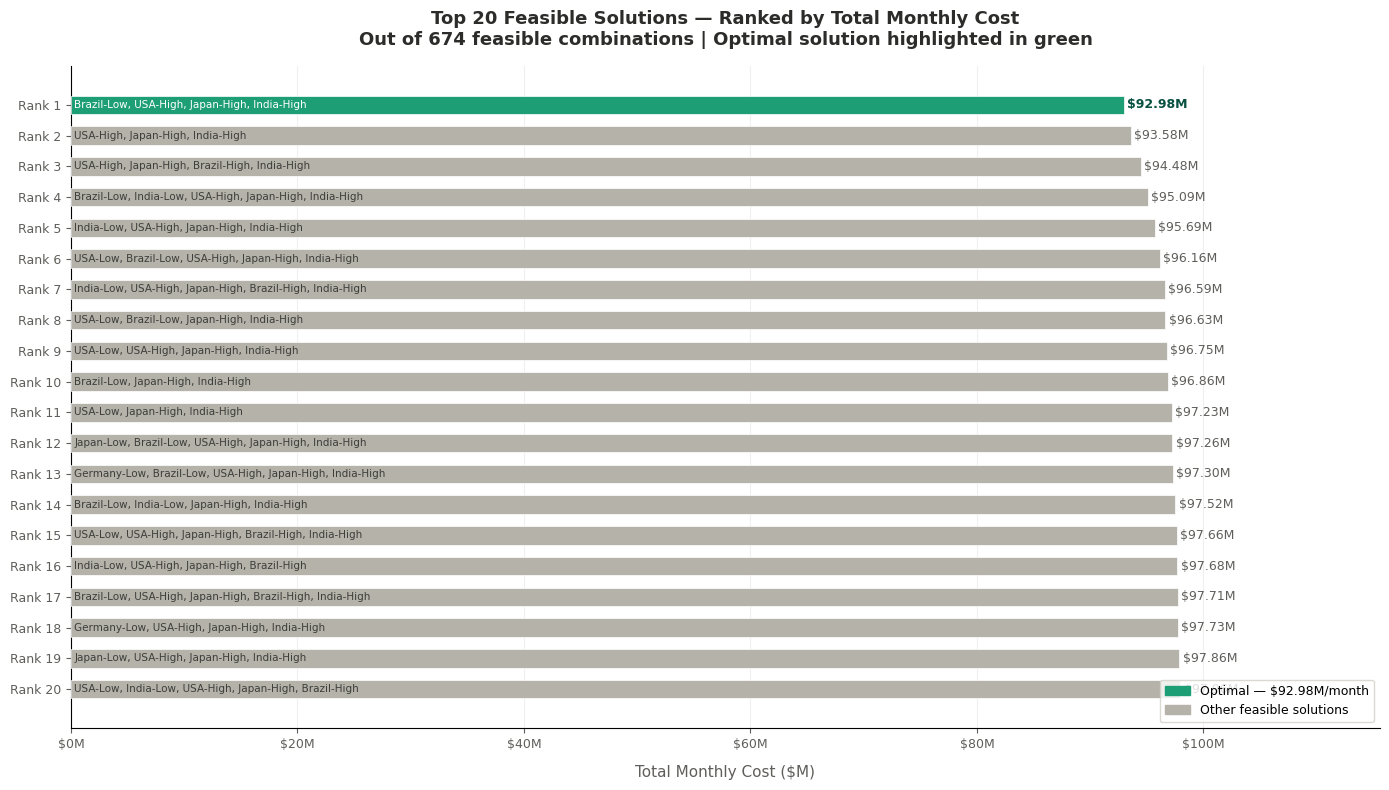

Saved: chart0_top20_solutions.png


In [29]:

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

top20      = results[:20]
ranks      = [f"Rank {r['rank']}" for r in top20]
costs      = [r['cost'] / 1e6 for r in top20]
plants     = [', '.join(r['plants']) for r in top20]
bar_colors = ['#1D9E75' if r['rank'] == 1 else '#B4B2A9' for r in top20]

bars = ax.barh(ranks[::-1], costs[::-1],
               color=bar_colors[::-1],
               height=0.6, zorder=3,
               edgecolor='white', linewidth=0.5)

for bar, cost, plant, r in zip(bars, costs[::-1],
                                plants[::-1], top20[::-1]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'${cost:.2f}M',
            va='center', ha='left', fontsize=9,
            color='#085041' if r['rank'] == 1 else '#5F5E5A',
            fontweight='bold' if r['rank'] == 1 else 'normal')

    ax.text(0.3,
            bar.get_y() + bar.get_height() / 2,
            ', '.join(r['plants']),
            va='center', ha='left', fontsize=7.5,
            color='white' if r['rank'] == 1 else '#3d3d3a')

ax.set_xlabel('Total Monthly Cost ($M)', fontsize=11, color='#5F5E5A', labelpad=10)
ax.set_title('Top 20 Feasible Solutions — Ranked by Total Monthly Cost\n'
             f'Out of 674 feasible combinations | Optimal solution highlighted in green',
             fontsize=13, fontweight='bold', color='#2C2C2A', pad=15)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.0f}M'))
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='both', labelsize=9, colors='#5F5E5A')
ax.grid(axis='x', alpha=0.2, zorder=0)
ax.set_xlim(0, max(costs) * 1.18)

optimal_patch = mpatches.Patch(color='#1D9E75', label=f'Optimal — $92.98M/month')
other_patch   = mpatches.Patch(color='#B4B2A9', label='Other feasible solutions')
ax.legend(handles=[optimal_patch, other_patch],
          fontsize=9, loc='lower right',
          frameon=True, edgecolor='#D3D1C7')

plt.tight_layout()
plt.savefig(
    r'C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization\chart0_top20_solutions.png',
    dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart0_top20_solutions.png")

In [38]:
!pip install geopandas

  Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/23.6 MB ? eta -:--:--
   --- ------------------------------------ 1.8/23.6 MB 10.6 MB/s eta 0:00:03
   -------- ------------------------------- 5.2/23.6 MB 14.2 MB/s eta 0:00:02
   --------------- ------------------------ 8.9/23.6 MB 15.1 MB/s eta 0:00:01
   --------------------- ------------------ 12.6/23.6 MB 16.0 MB/s eta 0:00:01
   ---------------------------- ----------- 16.5/23.6 MB 16.8 MB/s eta 0:00:01
   ---------------------------------- ----- 20.2/23.6 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------- 23.6/23.6 MB 16.5 MB/s  0:00:01
Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl (6.4 MB)
Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl (1.8 MB)

   ---------------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


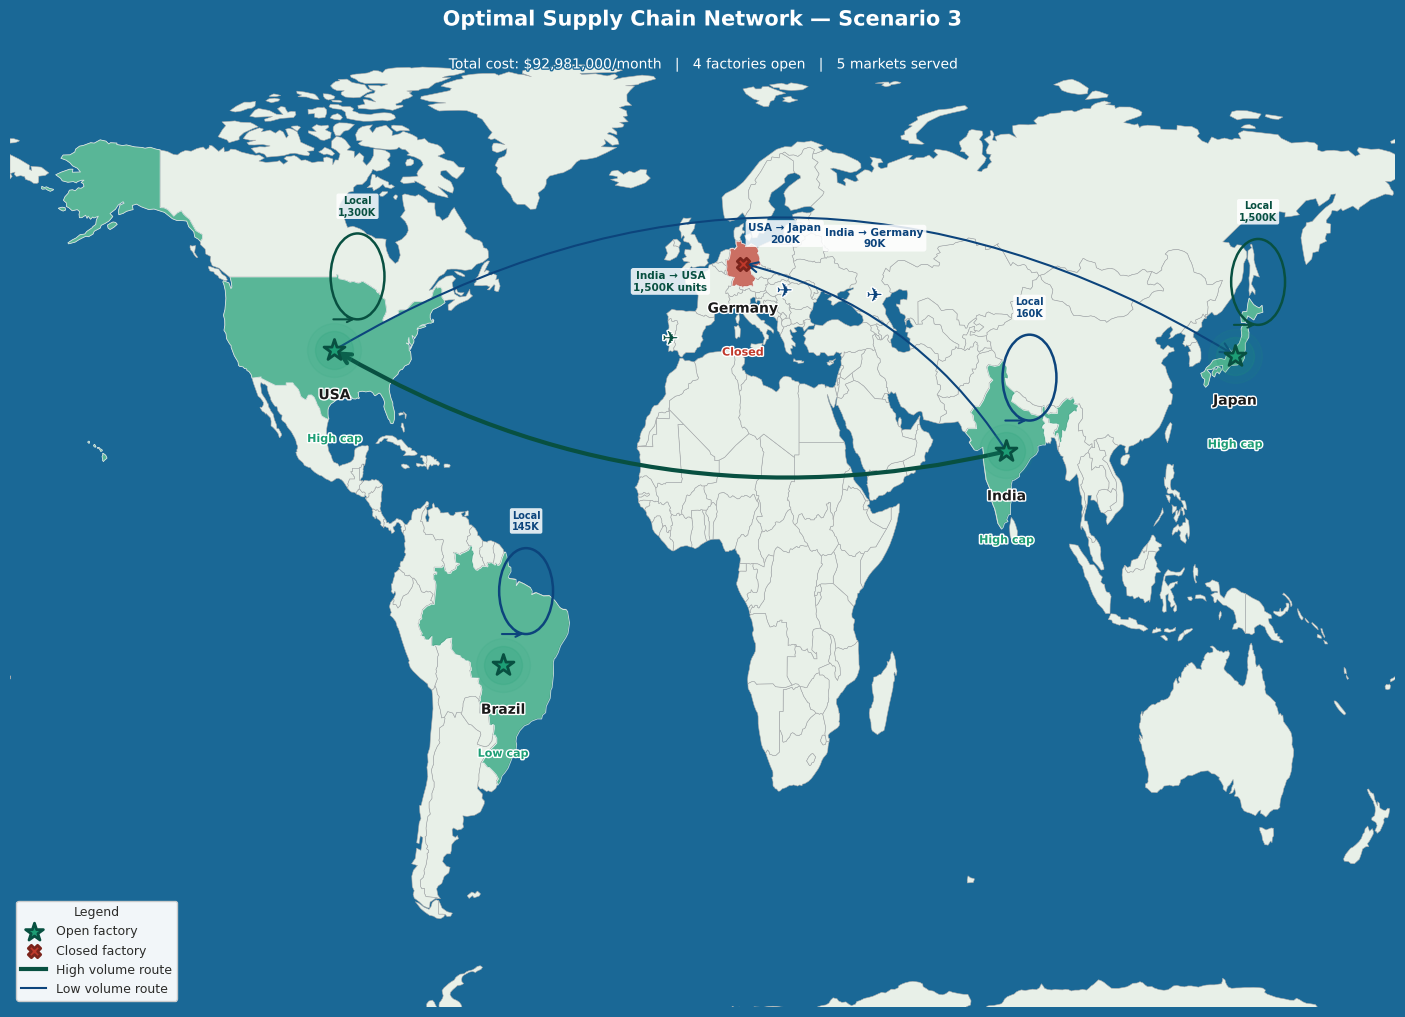

Saved: chart_globe.png


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import geopandas as gpd

# download world shapefile directly
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#1a6896')
ax.set_facecolor('#1a6896')

world.plot(ax=ax, color='#e8f0e8', edgecolor='#aaaaaa',
           linewidth=0.4, zorder=1)

ax.set_xlim(-180, 180)
ax.set_ylim(-70, 85)
ax.axis('off')

# highlight the 5 countries
highlight = {
    'India':                     '#1D9E75',
    'Brazil':                    '#1D9E75',
    'Japan':                     '#1D9E75',
    'United States of America':  '#1D9E75',
    'Germany':                   '#C0392B',
}
for country, color in highlight.items():
    world[world['NAME'] == country].plot(
        ax=ax, color=color, edgecolor='white',
        linewidth=0.6, zorder=2, alpha=0.7)

coords = {
    'India':   ( 78.9,  20.6),
    'Brazil':  (-51.9, -14.2),
    'Japan':   (138.3,  36.2),
    'USA':     (-95.7,  37.1),
    'Germany': ( 10.4,  51.2),
}

factories = [
    {'name':'India',   'open':True,  'cap':'High'},
    {'name':'Brazil',  'open':True,  'cap':'Low' },
    {'name':'Japan',   'open':True,  'cap':'High'},
    {'name':'USA',     'open':True,  'cap':'High'},
    {'name':'Germany', 'open':False, 'cap':'—'   },
]

routes = [
    {'from':'India', 'to':'USA',     'label':'India → USA\n1,500K units', 'col':'#085041','lw':3.0,'rad':-0.2},
    {'from':'India', 'to':'Germany', 'label':'India → Germany\n90K',      'col':'#0C447C','lw':1.5,'rad': 0.2},
    {'from':'USA',   'to':'Japan',   'label':'USA → Japan\n200K',         'col':'#0C447C','lw':1.5,'rad':-0.3},
]

self_routes = [
    {'name':'Japan',  'label':'Local\n1,500K','col':'#085041'},
    {'name':'USA',    'label':'Local\n1,300K','col':'#085041'},
    {'name':'India',  'label':'Local\n160K',  'col':'#0C447C'},
    {'name':'Brazil', 'label':'Local\n145K',  'col':'#0C447C'},
]

# international routes
for r in routes:
    x1,y1 = coords[r['from']]
    x2,y2 = coords[r['to']]
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(
                    arrowstyle='->', color=r['col'], lw=r['lw'],
                    connectionstyle=f"arc3,rad={r['rad']}",
                    mutation_scale=18), zorder=3)
    mx = (x1+x2)/2
    my = (y1+y2)/2
    ax.text(mx, my+10, '✈', fontsize=14, color=r['col'],
            ha='center', va='center', zorder=6,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    ax.text(mx, my+18, r['label'], ha='center', fontsize=7.5,
            color=r['col'], fontweight='bold', zorder=6,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      alpha=0.85, edgecolor='none'))

# local routes
for r in self_routes:
    x,y = coords[r['name']]
    circle = plt.Circle((x+6, y+12), 7,
                         fill=False, edgecolor=r['col'],
                         linewidth=1.8, zorder=3)
    ax.add_patch(circle)
    ax.annotate('', xy=(x+6, y+5), xytext=(x-1, y+5),
                arrowprops=dict(arrowstyle='->',
                                color=r['col'], lw=1.5), zorder=4)
    ax.text(x+6, y+22, r['label'], ha='center', fontsize=7,
            color=r['col'], fontweight='bold', zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.85, edgecolor='none'))

# factory markers
for f in factories:
    x,y = coords[f['name']]
    color  = '#1D9E75' if f['open'] else '#C0392B'
    border = '#085041' if f['open'] else '#7B241C'
    size   = 250 if f['open'] else 80
    marker = '*'  if f['open'] else 'X'

    if f['open']:
        for s,a in [(size*6,0.08),(size*3,0.15)]:
            ax.scatter(x, y, s=s, color=color, alpha=a, zorder=4)

    ax.scatter(x, y, s=size, color=color, edgecolors=border,
               linewidths=2, marker=marker, zorder=7)

    cap_txt = f['cap']+' cap' if f['open'] else 'Closed'
    ax.text(x, y-8, f['name'], ha='center', fontsize=10,
            color='#1a1a1a', fontweight='bold', zorder=8,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    ax.text(x, y-15, cap_txt, ha='center', fontsize=8,
            color=color, fontweight='bold', zorder=8,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

# title
ax.text(0, 90, 'Optimal Supply Chain Network — Scenario 3',
        ha='center', fontsize=15, fontweight='bold', color='white', zorder=9,
        path_effects=[pe.withStroke(linewidth=3, foreground='#1a6896')])
ax.text(0, 83, 'Total cost: $92,981,000/month   |   4 factories open   |   5 markets served',
        ha='center', fontsize=10, color='white', zorder=9,
        path_effects=[pe.withStroke(linewidth=2, foreground='#1a6896')])

# legend
legend = [
    plt.scatter([],[], s=180, marker='*', color='#1D9E75',
                edgecolors='#085041', linewidths=2, label='Open factory'),
    plt.scatter([],[], s=80,  marker='X', color='#C0392B',
                edgecolors='#7B241C', linewidths=2, label='Closed factory'),
    plt.Line2D([0],[0], color='#085041', lw=3,   label='High volume route'),
    plt.Line2D([0],[0], color='#0C447C', lw=1.5, label='Low volume route'),
]
leg = ax.legend(handles=legend, loc='lower left', fontsize=9,
                facecolor='white', edgecolor='#cccccc',
                labelcolor='#2C2C2A', framealpha=0.95,
                title='Legend', title_fontsize=9)
leg.get_title().set_color('#2C2C2A')

plt.tight_layout(pad=0.3)
plt.savefig(
    r'C:\Users\rvagh\OneDrive\Desktop\Supply Chain Network Optimization\chart_globe.png',
    dpi=150, bbox_inches='tight', facecolor='#1a6896')
plt.show()
print("Saved: chart_globe.png")

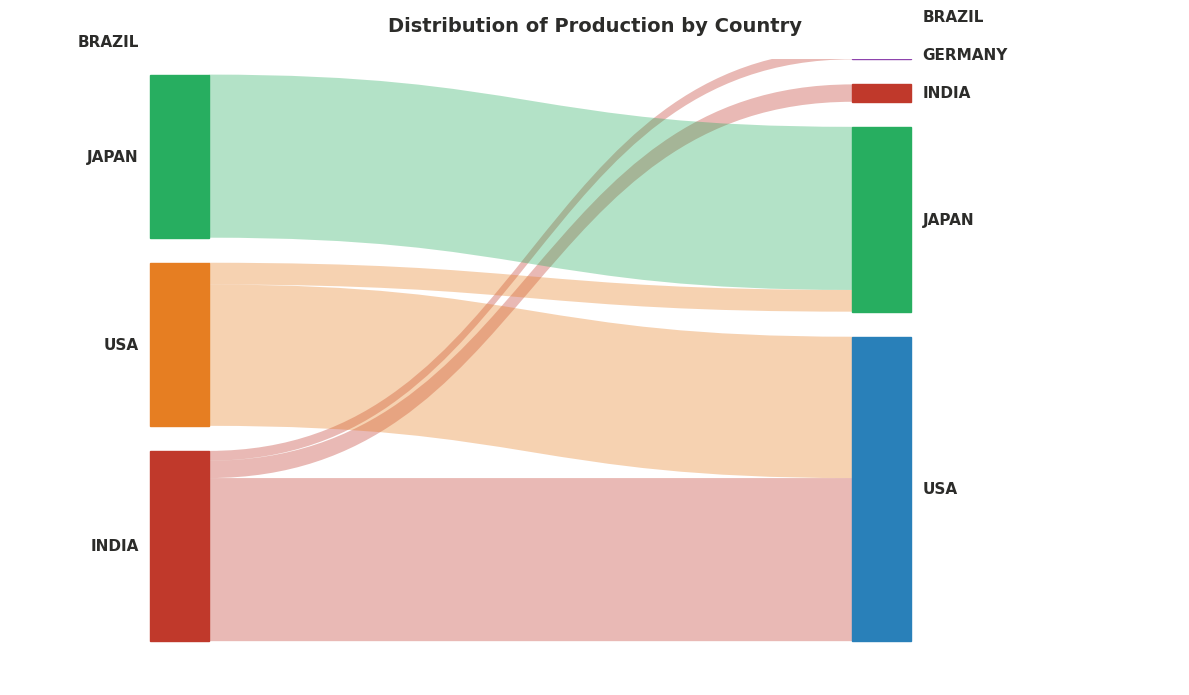

Saved: chart1_sankey.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 7))  #  Sankey chart
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
 
# --- data from your model results ---
sources = ['INDIA', 'USA', 'JAPAN', 'BRAZIL']
targets = ['USA', 'JAPAN', 'INDIA', 'GERMANY', 'BRAZIL']
src_colors = ['#C0392B', '#E67E22', '#27AE60', '#2980B9']
tgt_colors = ['#2980B9', '#27AE60', '#C0392B', '#8E44AD', '#E67E22']
 
flows = {
    ('INDIA',  'USA'):     1500,
    ('INDIA',  'INDIA'):   160,
    ('INDIA',  'GERMANY'): 90,
    ('USA',    'USA'):     1300,
    ('USA',    'JAPAN'):   200,
    ('JAPAN',  'JAPAN'):   1500,
    ('BRAZIL', 'BRAZIL'):  145,
}
 
src_totals = {s: sum(v for (src,_),v in flows.items() if src==s) for s in sources}
tgt_totals = {t: sum(v for (_,tgt),v in flows.items() if tgt==t) for t in targets}
total = sum(flows.values())
 
# draw source bars
lx, rx = 0.12, 0.72
bar_w = 0.05
y_gap = 0.04
avail = 0.85
 
src_bars, sy = {}, 0.07
for i, s in enumerate(sources):
    h = (src_totals[s] / total) * avail
    src_bars[s] = {'y': sy, 'h': h, 'color': src_colors[i]}
    ax.add_patch(plt.Rectangle((lx, sy), bar_w, h,
                 color=src_colors[i], transform=ax.transAxes, zorder=3))
    ax.text(lx - 0.01, sy + h/2, s, ha='right', va='center',
            fontsize=11, fontweight='bold', transform=ax.transAxes, color='#2C2C2A')
    sy += h + y_gap
 
tgt_bars, ty = {}, 0.07
for i, t in enumerate(targets):
    h = (tgt_totals[t] / total) * avail
    tgt_bars[t] = {'y': ty, 'h': h, 'color': tgt_colors[i]}
    ax.add_patch(plt.Rectangle((rx, ty), bar_w, h,
                 color=tgt_colors[i], transform=ax.transAxes, zorder=3))
    ax.text(rx + bar_w + 0.01, ty + h/2, t, ha='left', va='center',
            fontsize=11, fontweight='bold', transform=ax.transAxes, color='#2C2C2A')
    ty += h + y_gap
 
# draw flows
src_offsets = {s: 0 for s in sources}
tgt_offsets = {t: 0 for t in targets}
 
from matplotlib.patches import PathPatch
from matplotlib.path import Path
 
for (src, tgt), val in flows.items():
    sb = src_bars[src]; tb = tgt_bars[tgt]
    sh = (val / src_totals[src]) * sb['h']
    th = (val / tgt_totals[tgt]) * tb['h']
    sy0 = sb['y'] + src_offsets[src]
    ty0 = tb['y'] + tgt_offsets[tgt]
    x0 = lx + bar_w; x1 = rx
    mx = (x0 + x1) / 2
    verts = [(x0, sy0),(mx, sy0),(mx, ty0),(x1, ty0),
             (x1, ty0+th),(mx, ty0+th),(mx, sy0+sh),(x0, sy0+sh),(x0, sy0)]
    codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,
             Path.LINETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,Path.CLOSEPOLY]
    patch = PathPatch(Path(verts, codes),
                      facecolor=sb['color'], alpha=0.35, edgecolor='none',
                      transform=ax.transAxes, zorder=2)
    ax.add_patch(patch)
    src_offsets[src] += sh
    tgt_offsets[tgt] += th
 
ax.set_title('Distribution of Production by Country', fontsize=14,
             fontweight='bold', pad=20, color='#2C2C2A')
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'chart1_sankey.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart1_sankey.png")

In [28]:
from itertools import product
import pandas as pd
from pulp import *

results = []
combo_count = 0
feasible_count = 0

for combo in product([0,1], repeat=len(loc)*len(size)):
    combo_count += 1

    y_fixed = {}
    idx = 0
    for s in size:
        for i in loc:
            y_fixed[(i,s)] = combo[idx]
            idx += 1

    if sum(y_fixed.values()) == 0:
        continue

    total_cap = sum(cap.loc[i,s] * y_fixed[(i,s)] * 1000
                    for s in size for i in loc)
    total_dem = demand['Demand'].sum()
    if total_cap < total_dem:
        continue

    m = LpProblem(f"combo_{combo_count}", LpMinimize)
    xv = LpVariable.dicts(f"x{combo_count}_",
         [(i,j) for i in loc for j in loc],
         lowBound=0, cat='Continuous')

    m += (
        lpSum([fixed_costs.loc[i,s] * y_fixed[(i,s)] * 1000
               for s in size for i in loc])
      + lpSum([var_cost.loc[i,j] * xv[(i,j)]
               for i in loc for j in loc])
    )

    for j in loc:
        m += lpSum([xv[(i,j)] for i in loc]) == demand.loc[j,'Demand']
    for i in loc:
        m += lpSum([xv[(i,j)] for j in loc]) <= lpSum([
            cap.loc[i,s] * y_fixed[(i,s)] * 1000 for s in size])

    m.solve(PULP_CBC_CMD(msg=0))

    if LpStatus[m.status] == 'Optimal':
        feasible_count += 1
        cost = int(value(m.objective))
        open_plants = [f"{i}-{s}" for s in size
                       for i in loc if y_fixed[(i,s)] == 1]
        shipping = {f"{i}→{j}": int(value(xv[(i,j)]))
                    for i in loc for j in loc
                    if value(xv[(i,j)]) > 0}
        results.append({
            'rank':        0,
            'cost':        cost,
            'plants':      open_plants,
            'shipping':    shipping
        })

results.sort(key=lambda x: x['cost'])
for rank, r in enumerate(results, 1):
    r['rank'] = rank

print(f"Total combinations checked  : {combo_count}")
print(f"Total feasible solutions    : {feasible_count}")
print()
print("=" * 90)
print(f"{'Rank':<6} {'Cost ($/Month)':<22} {'Open Factories':<40} {'Shipping Routes'}")
print("=" * 90)

for r in results:
    marker     = ' ← OPTIMAL' if r['rank'] == 1 else ''
    plants_str = ', '.join(r['plants'])
    ships_str  = ', '.join([f"{k}:{v:,}" for k,v in r['shipping'].items()])
    print(f"{r['rank']:<6} ${r['cost']:>20,}  {plants_str:<40} {ships_str}{marker}")
    print("-" * 90)

print()
print(f"OPTIMAL : Rank 1 — ${results[0]['cost']:,}/month")
print(f"WORST   : Rank {len(results)} — ${results[-1]['cost']:,}/month")
print(f"DIFFERENCE : ${results[-1]['cost'] - results[0]['cost']:,}/month")

Total combinations checked  : 1024
Total feasible solutions    : 674

Rank   Cost ($/Month)         Open Factories                           Shipping Routes
1      $          92,981,000  Brazil-Low, USA-High, Japan-High, India-High USA→USA:1,300,000, USA→Japan:200,000, Japan→Japan:1,500,000, Brazil→Brazil:145,000, India→USA:1,500,000, India→Germany:90,000, India→India:160,000 ← OPTIMAL
------------------------------------------------------------------------------------------
2      $          93,579,000  USA-High, Japan-High, India-High         USA→USA:1,300,000, USA→Japan:200,000, Japan→Japan:1,500,000, India→USA:1,500,000, India→Germany:90,000, India→Brazil:145,000, India→India:160,000
------------------------------------------------------------------------------------------
3      $          94,481,000  USA-High, Japan-High, Brazil-High, India-High USA→USA:1,300,000, USA→Japan:200,000, Japan→Japan:1,500,000, Brazil→Brazil:145,000, India→USA:1,500,000, India→Germany:90,000, India→Ind